# Problem 1: Sequence Comparison Using RNNs

## Part 1: Explicit form of $h_T$

Unrolling the recurrence with $h_0 = 0$:

$$
h_T = \sum_{t=1}^{T/2} x_t \;-\; \sum_{t=T/2+1}^{T} x_t
$$

## Part 2: Function computed at the final step

$h_T$ computes the difference between the sum of the first half and the sum of the second half of the input sequence:

$$
h_T = S_{\text{first}} - S_{\text{second}}, \qquad S_{\text{first}} = \sum_{t=1}^{T/2} x_t, \quad S_{\text{second}} = \sum_{t=T/2+1}^{T} x_t
$$

Equivalently, $h_T = \sum_{t=1}^{T} c_t\, x_t$ where $c_t = +1$ for $t \le T/2$ and $c_t = -1$ for $t > T/2$.

## Part 3: Conditions on the output $y = \sigma(h_T)$ for $x_t \in \{0,1\}$

Since $\sigma$ is monotone increasing:

- $y \approx 1$ when $h_T > 0$, i.e. the first half has more 1s than the second half ($S_{\text{first}} > S_{\text{second}}$).
- $y \approx 0$ when $h_T < 0$, i.e. the second half has more 1s than the first half ($S_{\text{second}} > S_{\text{first}}$).
- $y \approx 0.5$ when the two halves have equal counts of 1s.

# Problem 2: Attention! My Code Takes Too Long

## Approach 1: Local / Sliding-Window Attention

Instead of attending to all $T$ tokens, each token attends only to a fixed window of $w$ neighboring tokens. The attention matrix becomes sparse with at most $w$ non-zero entries per row, so the total cost drops to $O(T \cdot w) = O(T)$ when $w$ is a constant.

Pros: simple to implement; preserves exact local context; used in Longformer.

Cons: tokens cannot directly attend to distant tokens, which can hurt tasks where long-range dependencies matter (e.g. question answering over long documents). Global tokens can partially compensate but add complexity.

## Approach 2: Linear Attention (Kernel Approximation)

Standard attention computes $\text{softmax}(QK^\top)V$. The softmax makes it hard to factor the $T \times T$ matrix. Linear attention replaces the softmax with a kernel function $\phi$ such that:

$$
\text{Attn}(q_i, K, V) = \frac{\phi(q_i)^\top \left(\sum_j \phi(k_j) v_j^\top\right)}{\phi(q_i)^\top \sum_j \phi(k_j)}
$$

The key insight is that $\sum_j \phi(k_j) v_j^\top$ (size $d \times d$) and $\sum_j \phi(k_j)$ (size $d$) can be computed once and reused across all queries, giving $O(T d^2)$ total, which is $O(T)$ in $T$.

Pros: exact linear scaling in sequence length; used in Performer and similar models.

Cons: the kernel approximation changes the attention distribution, so the model is no longer computing true softmax attention. This can degrade quality on tasks where the peaked, selective nature of softmax attention is important.

# Problem 3: Minimax Optimization

## Part 1: Saddle point

Taking partial derivatives and setting them to zero:

$$
\frac{\partial f}{\partial x} = 8(x - 1) = 0 \implies x^* = 1
$$

$$
\frac{\partial f}{\partial y} = -8(y + 2) = 0 \implies y^* = -2
$$

The saddle point is $(x^*, y^*) = (1, -2)$. It is a minimum along $x$ (since the $x$ term is convex) and a maximum along $y$ (since the $y$ term is concave).

## Part 2: Gradient descent/ascent equations

We descend on $x$ (minimize) and ascend on $y$ (maximize) with step size $\alpha$:

$$
x_{t+1} = x_t - \alpha \cdot 8(x_t - 1)
$$

$$
y_{t+1} = y_t + \alpha \cdot (-8)(y_t + 2) = y_t - 8\alpha(y_t + 2)
$$

## Part 3: Allowable step sizes for convergence

Both updates have the same structure. For $x$:

$$
x_{t+1} = (1 - 8\alpha)\, x_t + 8\alpha
$$

This is a linear recurrence that converges to $x^* = 1$ if and only if $|1 - 8\alpha| < 1$, which gives:

$$
0 < \alpha < \frac{1}{4}
$$

The $y$ update has the identical coefficient $(1 - 8\alpha)$, so it requires the same condition. The allowable range is $\alpha \in \left(0,\ \tfrac{1}{4}\right)$.

## Part 4: Regular gradient descent on both $x$ and $y$

With regular gradient descent we descend on both variables:

$$
y_{t+1} = y_t - \alpha \cdot \frac{\partial f}{\partial y} = y_t - \alpha \cdot (-8)(y_t + 2) = (1 + 8\alpha)\, y_t + 16\alpha
$$

Since $|1 + 8\alpha| > 1$ for any $\alpha > 0$, the $y$ update is an expanding recurrence and $y$ diverges to $-\infty$. Intuitively, $f$ is concave in $y$ (an upside-down parabola), so gradient descent on $y$ moves away from the maximum rather than toward it.

The only special case where you converge is if you start exactly at $y_0 = -2$, in which case the update gives $y_1 = -2$ and $y$ stays fixed. But this is unstable: any perturbation causes divergence. So in general, regular gradient descent does not converge to the saddle point.

## Part 5: Why minimax and not maxmin?

In a GAN, the generator $G$ and discriminator $D$ play opposing roles. The minimax formulation $\min_G \max_D$ reflects the true adversarial game: for any fixed $G$, we find the best possible discriminator (inner $\max$), then $G$ tries to minimize its loss against that best discriminator (outer $\min$). This gives $G$ no room to exploit a weak $D$.

Swapping to $\max_G \min_D$ would bad: first find the worst possible discriminator for each generator, then maximize against it. That is a fundamentally different and ill-posed problem. The generator would be optimizing against a discriminator that has been deliberately made weak, which provides no useful training signal and does not correspond to an adversarial game. The minimax order matches the causal structure of training: $D$ always responds optimally to whatever $G$ produces.

# Problem 4: GAN vs Conditional GAN

## Part (a): Standard GAN on FashionMNIST

Same MLP architecture as the demo but with no class conditioning. Both the generator and discriminator drop the label input entirely.

In [1]:
import torch
from torchvision import datasets
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.pyplot import imsave

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

batch_size = 64
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

fashion_data = datasets.FashionMNIST(root='../data/', train=True, transform=transform, download=True)
fashion_loader = DataLoader(dataset=fashion_data, batch_size=batch_size, shuffle=True, drop_last=True)

FASHION_CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"FashionMNIST loaded: {len(fashion_data)} training images")

FashionMNIST loaded: 60000 training images


In [2]:
# No class label input

class StandardGenerator(nn.Module):
    def __init__(self, input_size=100, image_size=28*28):
        super(StandardGenerator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        y_ = self.network(x)
        return y_.view(x.size(0), 1, 28, 28)


class StandardDiscriminator(nn.Module):
    def __init__(self, input_size=28*28, num_output=1):
        super(StandardDiscriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_output),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

Epoch 0/50  Step 0  D: 1.4144  G: 0.6746
Epoch 0/50  Step 500  D: 1.2266  G: 0.8509
Epoch 1/50  Step 1000  D: 1.2633  G: 1.0895
Epoch 1/50  Step 1500  D: 1.3583  G: 0.8406
Epoch 2/50  Step 2000  D: 1.3472  G: 0.8827
Epoch 2/50  Step 2500  D: 1.2796  G: 1.2024
Epoch 3/50  Step 3000  D: 1.2983  G: 0.8385
Epoch 3/50  Step 3500  D: 1.3816  G: 0.8053
Epoch 4/50  Step 4000  D: 1.3087  G: 0.9420
Epoch 4/50  Step 4500  D: 1.2705  G: 1.0259
Epoch 5/50  Step 5000  D: 1.3351  G: 0.7791
Epoch 5/50  Step 5500  D: 1.3363  G: 0.8887
Epoch 6/50  Step 6000  D: 1.2832  G: 0.9109
Epoch 6/50  Step 6500  D: 1.3617  G: 0.7694
Epoch 7/50  Step 7000  D: 1.4084  G: 0.7757
Epoch 8/50  Step 7500  D: 1.3311  G: 0.8456
Epoch 8/50  Step 8000  D: 1.3688  G: 0.6916
Epoch 9/50  Step 8500  D: 1.3155  G: 0.8152
Epoch 9/50  Step 9000  D: 1.3795  G: 0.8728
Epoch 10/50  Step 9500  D: 1.3655  G: 0.8800
Epoch 10/50  Step 10000  D: 1.3999  G: 0.6778
Epoch 11/50  Step 10500  D: 1.4189  G: 0.8345
Epoch 11/50  Step 11000  D: 1.3

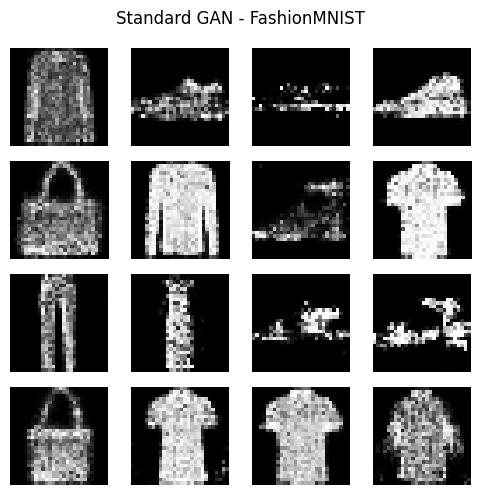

In [3]:
n_noise = 100
max_epoch = 50  
step_std = 0

D_std = StandardDiscriminator().to(DEVICE)
G_std = StandardGenerator().to(DEVICE)

criterion_std = nn.BCELoss()
D_std_opt = torch.optim.Adam(D_std.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_std_opt = torch.optim.Adam(G_std.parameters(), lr=0.0002, betas=(0.5, 0.999))

D_labels = torch.ones([batch_size, 1]).to(DEVICE)
D_fakes  = torch.zeros([batch_size, 1]).to(DEVICE)

os.makedirs('samples_std', exist_ok=True)
std_d_losses, std_g_losses = [], []

for epoch in range(max_epoch):
    for images, _ in fashion_loader:
        x = images.to(DEVICE)

        # Train Discriminator
        x_out  = D_std(x)
        D_x_loss = criterion_std(x_out, D_labels)

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        z_out  = D_std(G_std(z))
        D_z_loss = criterion_std(z_out, D_fakes)
        D_loss = D_x_loss + D_z_loss

        D_std.zero_grad()
        D_loss.backward()
        D_std_opt.step()

        # Train Generator
        z = torch.randn(batch_size, n_noise).to(DEVICE)
        z_out  = D_std(G_std(z))
        G_loss = criterion_std(z_out, D_labels)

        G_std.zero_grad()
        G_loss.backward()
        G_std_opt.step()

        std_d_losses.append(D_loss.item())
        std_g_losses.append(G_loss.item())
        if step_std % 500 == 0:
            print(f'Epoch {epoch}/{max_epoch}  Step {step_std}  D: {D_loss.item():.4f}  G: {G_loss.item():.4f}')
        step_std += 1

# Sample grid
G_std.eval()
with torch.no_grad():
    z = torch.randn(16, n_noise).to(DEVICE)
    samples = G_std(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Standard GAN - FashionMNIST')
plt.tight_layout()
plt.show()

## Part (b): Conditional GAN on FashionMNIST

In [4]:
# A transform to convert the images to tensor and normalize their RGB values
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5], std=[0.5])]
)

data = datasets.FashionMNIST(root='../data/', train=True, transform=transform, download=True)

batch_size = 64
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, drop_last=True)

In [5]:
def to_onehot(x, num_classes=10):
    assert isinstance(x, int) or isinstance(x, (torch.LongTensor, torch.cuda.LongTensor))
    if isinstance(x, int):
        c = torch.zeros(1, num_classes).long()
        c[0][x] = 1
    else:
        x = x.cpu()
        c = torch.LongTensor(x.size(0), num_classes)
        c.zero_()
        c.scatter_(1, x, 1) # dim, index, src value
    return c

In [6]:
def get_sample_image(G, DEVICE, n_noise=100):
    img = np.zeros([280, 280])
    for j in range(10):
        c = torch.zeros([10, 10]).to(DEVICE)
        c[:, j] = 1
        z = torch.randn(10, n_noise).to(DEVICE)
        y_hat = G(z,c).view(10, 28, 28)
        result = y_hat.cpu().data.numpy()
        img[j*28:(j+1)*28] = np.concatenate([x for x in result], axis=-1)
    return img

## Architecture

We now instantiate the generator and discriminator architectures. The generator takes a random noise vector and a one hot encoded label as input and produces an image. The discriminator takes an image and a one hot encoded label as input and produces a single value between 0 and 1. The discriminator is trained to output 1 for real images and 0 for fake images. The generator is trained to fool the discriminator by outputting images that look real.

In [7]:
class Generator(nn.Module):
    def __init__(self, input_size=100, num_classes=10, image_size=28*28):
        super(Generator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size+num_classes, 128), # auxillary dimension for label
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()
        )
        
    def forward(self, x, c):
        x, c = x.view(x.size(0), -1), c.view(c.size(0), -1).float()
        v = torch.cat((x, c), 1) # v: [input, label] concatenated vector
        y_ = self.network(v)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [8]:
class Discriminator(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, num_output=1):
        super(Discriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size+num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_output),
            nn.Sigmoid(),
        )
    
    def forward(self, x, c):        
        x, c = x.view(x.size(0), -1), c.view(c.size(0), -1).float()
        v = torch.cat((x, c), 1) # v: [input, label] concatenated vector
        y_ = self.network(v)
        return y_

In [9]:
MODEL_NAME = 'ConditionalGAN'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

D = Discriminator().to(DEVICE)
G = Generator().to(DEVICE)

max_epoch = 50  # RTX 3080
step = 0
n_noise = 100 # size of noise vector

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

# This is why we needed to drop the last batch of the data loader
D_labels = torch.ones([batch_size, 1]).to(DEVICE) # Discriminator label: real
D_fakes = torch.zeros([batch_size, 1]).to(DEVICE) # Discriminator Label: fake

In [10]:
# a directory to save the generated images
if not os.path.exists('samples'):
    os.makedirs('samples')

for epoch in range(max_epoch):
    for idx, (images, labels) in enumerate(data_loader):
        # Training Discriminator
        x = images.to(DEVICE)
        y = labels.view(batch_size, 1) # add singleton dimension so batch_size x 1
        y = to_onehot(y).to(DEVICE)
        x_outputs = D(x, y) # input includes labels
        D_x_loss = criterion(x_outputs, D_labels) # Discriminator loss for real images

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        z_outputs = D(G(z, y), y) # input to both generator and discriminator includes labels
        D_z_loss = criterion(z_outputs, D_fakes) # Discriminator loss for fake images
        D_loss = D_x_loss + D_z_loss # Total Discriminator loss
        
        D.zero_grad()
        D_loss.backward()
        D_opt.step()
        
        # Training Generator
        z = torch.randn(batch_size, n_noise).to(DEVICE)
        z_outputs = D(G(z, y), y)
        G_loss = -1 * criterion(z_outputs, D_fakes) # Generator loss is negative disciminator loss

        G.zero_grad()
        G_loss.backward()
        G_opt.step()
        
        if step % 500 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(epoch, max_epoch, step, D_loss.item(), G_loss.item()))
        
        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, DEVICE, n_noise)
            imsave('samples/{}_step{}.jpg'.format(MODEL_NAME, str(step).zfill(3)), img, cmap='gray')
            G.train()
        step += 1

Epoch: 0/50, Step: 0, D Loss: 1.3727142810821533, G Loss: -0.6746495962142944
Epoch: 0/50, Step: 500, D Loss: 1.0983887910842896, G Loss: -0.25398340821266174
Epoch: 1/50, Step: 1000, D Loss: 1.1945360898971558, G Loss: -0.33214500546455383
Epoch: 1/50, Step: 1500, D Loss: 1.354251742362976, G Loss: -0.5457920432090759
Epoch: 2/50, Step: 2000, D Loss: 1.286820650100708, G Loss: -0.4640067517757416
Epoch: 2/50, Step: 2500, D Loss: 1.3724396228790283, G Loss: -0.6192212104797363
Epoch: 3/50, Step: 3000, D Loss: 1.346423864364624, G Loss: -0.5837974548339844
Epoch: 3/50, Step: 3500, D Loss: 1.418931245803833, G Loss: -0.5861095190048218
Epoch: 4/50, Step: 4000, D Loss: 1.3162729740142822, G Loss: -0.5903406143188477
Epoch: 4/50, Step: 4500, D Loss: 1.437910556793213, G Loss: -0.6450945138931274
Epoch: 5/50, Step: 5000, D Loss: 1.3005183935165405, G Loss: -0.6024855375289917
Epoch: 5/50, Step: 5500, D Loss: 1.3807483911514282, G Loss: -0.5392487049102783
Epoch: 6/50, Step: 6000, D Loss: 1.

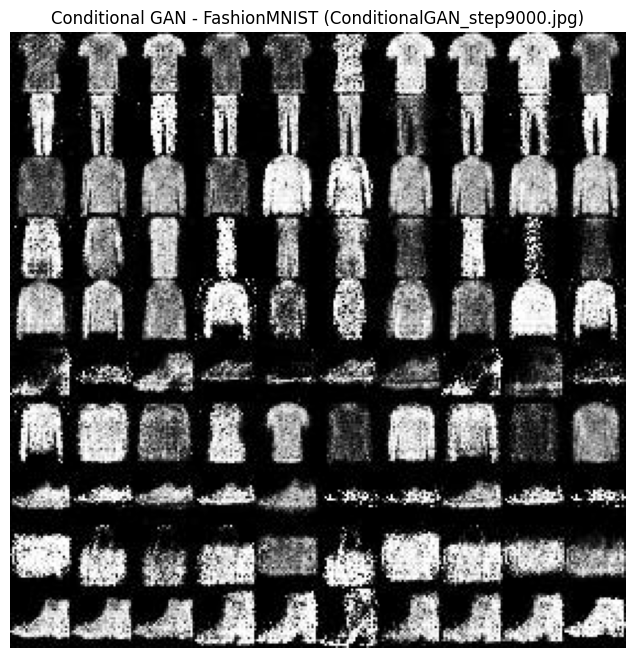

In [11]:
# Display final conditional GAN samples
import glob, os
saved = sorted(glob.glob('samples/ConditionalGAN_step*.jpg'))
if saved:
    img = mpimg.imread(saved[-1])
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'Conditional GAN - FashionMNIST ({os.path.basename(saved[-1])})')
    plt.show()


## Part (c): GAN Quality Measures

Common metrics for evaluating GAN sample quality:

Frechet Inception Distance (FID): Embeds real and generated images into a pretrained Inception network, then compares the mean and covariance of the resulting feature distributions. Lower FID means the generated distribution is closer to the real one. FID is the most widely used single-number GAN metric.

Inception Score (IS): Also uses a pretrained Inception network. A good generator should produce images that are confidently classifiable (low entropy per sample) and  cover many classes across the full set of samples (high entropy of the marginal). IS is the exponential of the expected KL divergence between these two distributions. Higher is better, but IS is less reliable than FID because it ignores the real data distribution entirely.

Precision and Recall: Precision measures what fraction of generated samples fall inside the real data manifold. Recall measures what fraction of the real data manifold is covered by the generator (diversity).

## Part (d): GAN vs Conditional GAN Comparison

Both models used the same MLP architecture, FashionMNIST dataset, and Adam optimizer (lr=0.0002) for 50 epochs.

Standard GAN: The 4x4 sample grid shows clearly recognizable FashionMNIST garments: trousers, coats, shirts, bags, and shoes are all visible with reasonable shape fidelity. However, there is no control over which class is generated; the 16 samples span multiple random categories.

Conditional GAN: The 10x10 sample grid (one column per class) shows that conditioning works. Each row is visually distinct and corresponds to its label, trousers have the characteristic vertical elongated silhouette, upper-body garments show the expected boxy torso shape, sandals appear as flat horizontal objects, and bags appear as rectangular blobs. The key advantage over the standard GAN is controllability: you can request a specific class and reliably get samples from that class.

Trade-offs: The conditional GAN images are slightly noisier than the standard GAN samples. This is expected, the conditional model has a harder task and the discriminator also receives label information which changes the training dynamics. Both models converged stably with no mode collapse observed.

# Problem 5: A Tiny Diffusion Model on FashionMNIST

Based on `demo13-diffusion.ipynb`. Parts (a)-(c) adapt the demo architecture to FashionMNIST and investigate the effect of the noise schedule.

## Part (a): FashionMNIST Diffusion Model

The only required code change from the demo is replacing `torchvision.datasets.MNIST` with `torchvision.datasets.FashionMNIST`. The transform, model architecture (`Diffuser`), optimizer, loss function, and training loop are all unchanged. FashionMNIST shares MNIST's 28x28 grayscale format and 10 classes, so the dimensionality of every layer is identical.

Sample quality: After 25 epochs, the generated images are noisy and mostly indistinct, recognizable structure is largely absent. This is a consequence of the architecture: the 2-layer MLP has no spatial inductive bias, so it cannot effectively learn to remove noise from specific spatial regions. The model does reduce noise compared to random initialization, but the output remains grainy blobs rather than clean garment images.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

diff_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Same transform as demo 
diff_train_data = torchvision.datasets.FashionMNIST(
    '../data/', train=True, download=True, transform=torchvision.transforms.ToTensor()
)
print(f'FashionMNIST: {len(diff_train_data)} training images')

diff_batch_size = 512
diff_loader = torch.utils.data.DataLoader(diff_train_data, batch_size=diff_batch_size, drop_last=True)

DIFF_CLASSES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

FashionMNIST: 60000 training images


In [13]:
def diff_normalize(x, sigma):
    mean = x.mean(dim=-1).view(-1, 1)
    std = x.std(dim=-1).view(-1, 1)
    return (x - mean) / std * sigma

class Diffuser(nn.Module):
    def __init__(self, sigma, noise_steps):
        super(Diffuser, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(28*28 + noise_steps + 10, 28*28),
            nn.ReLU(),
            nn.Linear(28*28, 28*28)
        )
        self.sigma = sigma
        self.noise_steps = noise_steps

    def forward(self, images, noise_level, labels):
        images = images.view(-1, 28*28)
        noise_level_enc = F.one_hot(
            torch.tensor([noise_level] * images.shape[0]), num_classes=self.noise_steps
        ).to(diff_device)
        labels_enc = F.one_hot(labels, num_classes=10).to(diff_device)
        x = torch.cat((images, noise_level_enc, labels_enc), 1)
        x = self.layers(x)
        x = diff_normalize(x, self.sigma)
        return x.view(-1, 1, 28, 28)

Epoch 1/25  Loss: 456.5
Epoch 2/25  Loss: 405.9
Epoch 3/25  Loss: 393.4
Epoch 4/25  Loss: 385.7
Epoch 5/25  Loss: 382.1
Epoch 6/25  Loss: 377.4
Epoch 7/25  Loss: 376.3
Epoch 8/25  Loss: 374.6
Epoch 9/25  Loss: 373.8
Epoch 10/25  Loss: 372.5
Epoch 11/25  Loss: 372.1
Epoch 12/25  Loss: 371.1
Epoch 13/25  Loss: 370.6
Epoch 14/25  Loss: 370.7
Epoch 15/25  Loss: 370.2
Epoch 16/25  Loss: 369.9
Epoch 17/25  Loss: 369.1
Epoch 18/25  Loss: 369.5
Epoch 19/25  Loss: 368.3
Epoch 20/25  Loss: 368.5
Epoch 21/25  Loss: 368.0
Epoch 22/25  Loss: 368.1
Epoch 23/25  Loss: 367.8
Epoch 24/25  Loss: 367.7
Epoch 25/25  Loss: 367.5


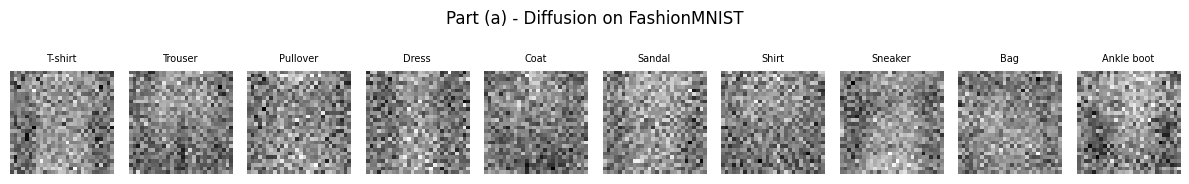

In [14]:
sigma = 0.35
noise_steps = 20

diff_model = Diffuser(sigma, noise_steps).to(diff_device)
diff_optimizer = torch.optim.Adam(diff_model.parameters(), lr=1)
diff_criterion = nn.MSELoss()

unit_normal = torch.distributions.Normal(0, sigma)
unit_normal.loc = unit_normal.loc.to(diff_device)
unit_normal.scale = unit_normal.scale.to(diff_device)

def diff_evaluate(model, noise_steps, caption=''):
    noisy = unit_normal.sample((10, 1, 28, 28)) * np.sqrt(noise_steps)
    labels = torch.arange(10)
    with torch.no_grad():
        for t in range(noise_steps):
            noise_level = noise_steps - t - 1
            noise = model(noisy, noise_level, labels)
            noisy -= noise
    fig, axes = plt.subplots(1, 10, figsize=(12, 2))
    for i, ax in enumerate(axes):
        ax.imshow(noisy[i].cpu().squeeze(), cmap='gray')
        ax.set_title(DIFF_CLASSES[i], fontsize=7)
        ax.axis('off')
    plt.suptitle(caption if caption else 'Diffusion samples')
    plt.tight_layout()
    plt.show()

num_epochs_diff = 25
for epoch in range(num_epochs_diff):
    epoch_loss = 0
    for images, labels in diff_loader:
        images = images.to(diff_device)
        for noise_level in torch.randperm(noise_steps):
            noise_level = noise_level.item()
            less_noisy = images + unit_normal.sample(images.shape) * np.sqrt(noise_level)
            one_step_noise = unit_normal.sample(images.shape)
            more_noisy = less_noisy + one_step_noise
            output = diff_model(more_noisy, noise_level, labels)
            loss = diff_criterion(output, one_step_noise)
            diff_optimizer.zero_grad()
            loss.backward()
            diff_optimizer.step()
            epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{num_epochs_diff}  Loss: {epoch_loss:.1f}')

diff_evaluate(diff_model, noise_steps, 'Part (a) - Diffusion on FashionMNIST')

## Part (b): Forward Diffusion Visualization

Using the demo's variance trick: after $t$ steps of adding noise with standard deviation $\sigma$, the cumulative noisy image is distributed as $x_0 + \mathcal{N}(0,\, t \sigma^2)$, so we can sample it directly without iterating.

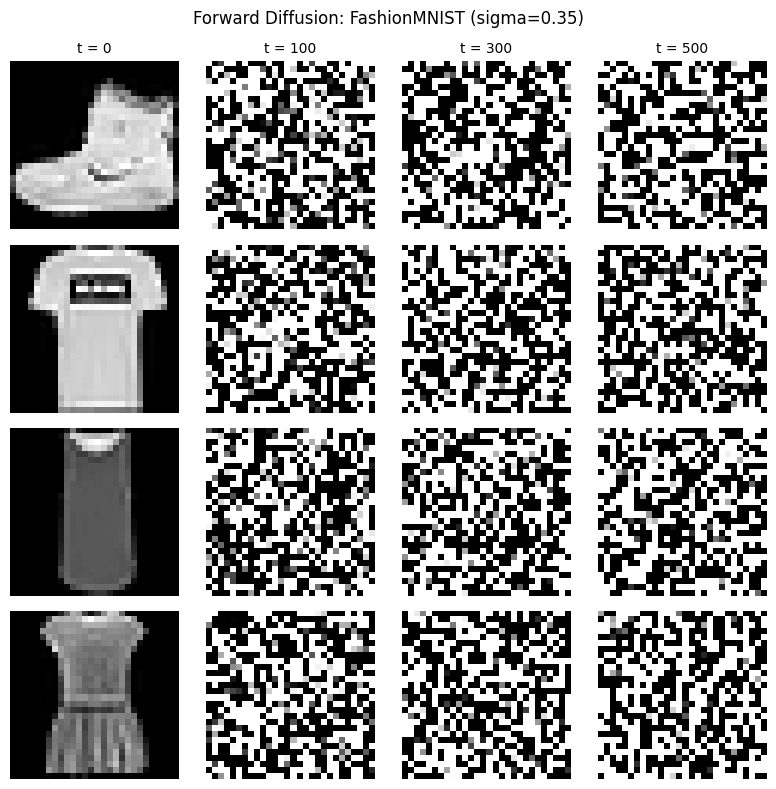

In [15]:
noise_levels_vis = [0, 100, 300, 500]
images_vis, labels_vis = next(iter(diff_loader))
x0_vis = images_vis[:4]  # 4 sample images

fig, axes = plt.subplots(4, len(noise_levels_vis), figsize=(len(noise_levels_vis)*2, 8))
for row in range(4):
    for col, t in enumerate(noise_levels_vis):
        if t == 0:
            x_t = x0_vis[row]
        else:
            noise = torch.normal(0, sigma * np.sqrt(t), x0_vis[row].shape)
            x_t = x0_vis[row] + noise
        axes[row, col].imshow(x_t.squeeze().clamp(0, 1), cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f't = {t}', fontsize=10)

plt.suptitle('Forward Diffusion: FashionMNIST (sigma=0.35)')
plt.tight_layout()
plt.show()

### Part (b) Observations

At $t=0$ the image is unmodified. As $t$ increases, the cumulative noise standard deviation grows as $\sigma\sqrt{t}$, so the signal-to-noise ratio decreases. High-frequency details (sharp edges of garments, fine textures) are the first to be swamped because they contribute little total intensity relative to the added noise variance. By $t=100$, most fine detail is lost and only the coarsest shape (a faint silhouette) remains visible. By $t=300$, essentially all signal is destroyed: the cumulative standard deviation is $0.35\sqrt{300} \approx 6.06$, far exceeding the $[0,1]$ pixel range. By $t=500$ ($\sigma\sqrt{500} \approx 7.83$) the image is pure Gaussian noise with no visible trace of the original.

## Part (c): Noise Schedule Ablation

The demo uses a uniform (constant) per-step sigma, which means cumulative noise variance grows linearly: $\text{Var}(x_t) = t \sigma^2$. This is the "linear" schedule. Here we also implement a cosine-like schedule where cumulative variance follows a cosine curve, concentrating large noise additions toward later steps. Both schedules use the same total noise budget.

We train two separate models (same architecture, 8 epochs each) and compare training loss curves and sample quality.

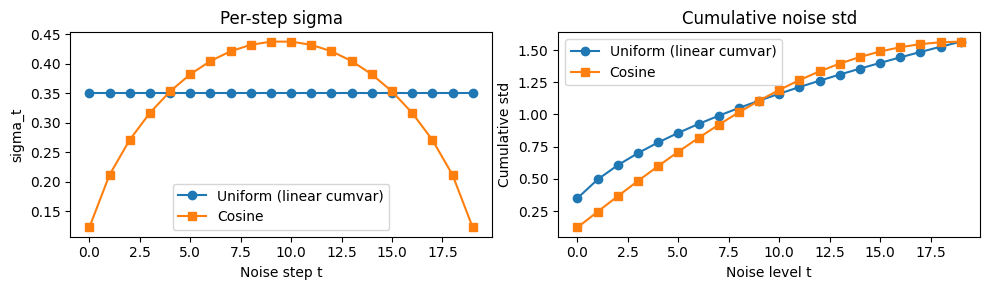

In [16]:
T_abl = 20
sigma_base = 0.35

# Linear (uniform): each step adds the same noise 
sigmas_linear = torch.full((T_abl,), sigma_base)

# Same total variance as uniform schedule: total_var = T * sigma_base^2
total_var = T_abl * sigma_base**2
t_idx = torch.arange(1, T_abl + 1, dtype=torch.float32)
cum_var_cosine = total_var * (1 - torch.cos(torch.pi * t_idx / T_abl)) / 2
cum_var_prev   = torch.cat([torch.zeros(1), cum_var_cosine[:-1]])
sigmas_cosine  = torch.sqrt(cum_var_cosine - cum_var_prev)

# Cumulative std for sampling at a given level
cum_std_linear = torch.sqrt(torch.cumsum(sigmas_linear**2, dim=0))
cum_std_cosine = torch.sqrt(cum_var_cosine)

# Visualize how the two schedules differ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(sigmas_linear.numpy(), label='Uniform (linear cumvar)', marker='o')
ax1.plot(sigmas_cosine.numpy(), label='Cosine', marker='s')
ax1.set_xlabel('Noise step t'); ax1.set_ylabel('sigma_t'); ax1.legend()
ax1.set_title('Per-step sigma')
ax2.plot(cum_std_linear.numpy(), label='Uniform (linear cumvar)', marker='o')
ax2.plot(cum_std_cosine.numpy(), label='Cosine', marker='s')
ax2.set_xlabel('Noise level t'); ax2.set_ylabel('Cumulative std'); ax2.legend()
ax2.set_title('Cumulative noise std')
plt.tight_layout(); plt.show()

In [17]:
class DiffuserSched(nn.Module):
    def __init__(self, sigmas):
        super().__init__()
        self.sigmas = sigmas
        T = len(sigmas)
        self.layers = nn.Sequential(
            nn.Linear(28*28 + T + 10, 28*28),
            nn.ReLU(),
            nn.Linear(28*28, 28*28)
        )
        self.T = T

    def forward(self, images, noise_level, labels):
        images = images.to(diff_device).view(-1, 28*28)
        nl_enc = F.one_hot(
            torch.tensor([noise_level] * images.shape[0]), num_classes=self.T
        ).to(diff_device)
        lbl_enc = F.one_hot(labels.to(diff_device), num_classes=10).to(diff_device)
        x = torch.cat((images, nl_enc, lbl_enc), 1)
        x = self.layers(x)
        sigma_t = self.sigmas[noise_level].to(diff_device)
        mean = x.mean(dim=-1, keepdim=True)
        std  = x.std(dim=-1, keepdim=True)
        x = (x - mean) / (std + 1e-8) * sigma_t
        return x.view(-1, 1, 28, 28)

def train_sched(model, loader, sigmas, cum_stds, num_epochs=8):
    optimizer = torch.optim.Adam(model.parameters(), lr=1)
    criterion = nn.MSELoss()
    T = len(sigmas)
    losses = []
    for epoch in range(num_epochs):
        epoch_loss = 0
        for images, labels in loader:
            images = images.to(diff_device)
            for t in torch.randperm(T):
                t = t.item()
                cs = cum_stds[t - 1].item() if t > 0 else 0.0
                st = sigmas[t].item()
                less_noisy    = images + torch.randn_like(images) * cs
                one_step_noise = torch.randn_like(images) * st
                more_noisy    = less_noisy + one_step_noise
                output = model(more_noisy, t, labels)
                loss = criterion(output, one_step_noise)
                optimizer.zero_grad(); loss.backward(); optimizer.step()
                epoch_loss += loss.item()
        losses.append(epoch_loss)
        print(f'  Epoch {epoch+1}/{num_epochs}  Loss: {epoch_loss:.1f}')
    return losses

def eval_sched(model, sigmas, cum_stds, caption=''):
    T = len(sigmas)
    total_std = cum_stds[-1].item()
    # 16 samples: cycle through all 10 classes
    labels16 = torch.tensor([i % 10 for i in range(16)]).to(diff_device)
    x = (torch.randn(16, 1, 28, 28) * total_std).to(diff_device)
    model.eval()
    with torch.no_grad():
        for t in range(T - 1, -1, -1):
            noise_pred = model(x, t, labels16)
            x -= noise_pred
    fig, axes = plt.subplots(4, 4, figsize=(5, 5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(x[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(caption)
    plt.tight_layout(); plt.show()

Training with linear (uniform) schedule...
  Epoch 1/8  Loss: 459.3
  Epoch 2/8  Loss: 407.7
  Epoch 3/8  Loss: 395.0
  Epoch 4/8  Loss: 387.4
  Epoch 5/8  Loss: 382.4
  Epoch 6/8  Loss: 378.3
  Epoch 7/8  Loss: 376.6
  Epoch 8/8  Loss: 374.7

Training with cosine schedule...
  Epoch 1/8  Loss: 451.0
  Epoch 2/8  Loss: 392.6
  Epoch 3/8  Loss: 379.7
  Epoch 4/8  Loss: 371.3
  Epoch 5/8  Loss: 365.9
  Epoch 6/8  Loss: 362.9
  Epoch 7/8  Loss: 360.4
  Epoch 8/8  Loss: 359.4


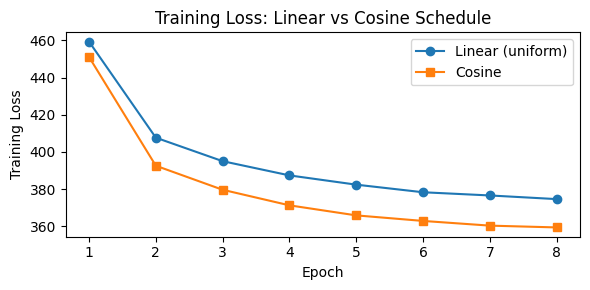

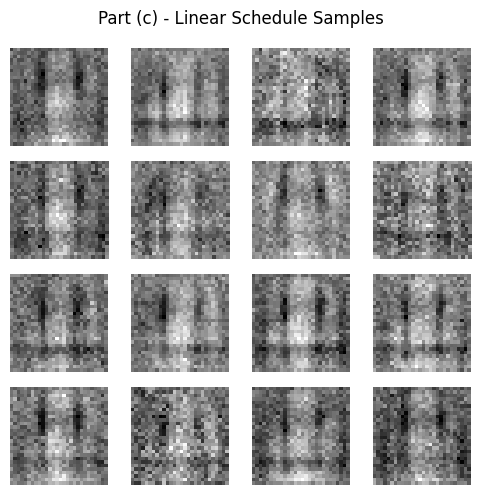

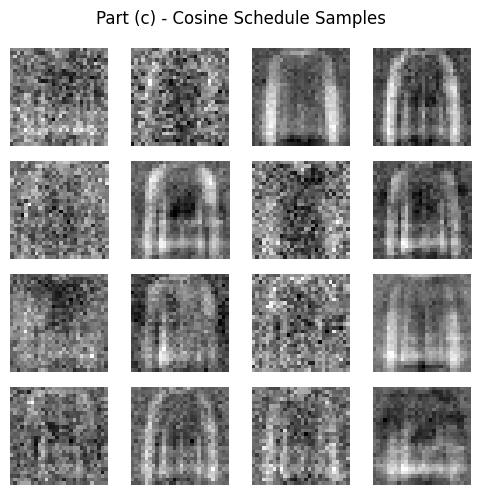

In [18]:
# Train both models
print("Training with linear (uniform) schedule...")
model_lin_abl = DiffuserSched(sigmas_linear).to(diff_device)
losses_lin = train_sched(model_lin_abl, diff_loader, sigmas_linear, cum_std_linear, num_epochs=8)

print("\nTraining with cosine schedule...")
model_cos_abl = DiffuserSched(sigmas_cosine).to(diff_device)
losses_cos = train_sched(model_cos_abl, diff_loader, sigmas_cosine, cum_std_cosine, num_epochs=8)

# Loss curves
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, 9), losses_lin, label='Linear (uniform)', marker='o')
ax.plot(range(1, 9), losses_cos, label='Cosine', marker='s')
ax.set_xlabel('Epoch'); ax.set_ylabel('Training Loss')
ax.set_title('Training Loss: Linear vs Cosine Schedule')
ax.legend(); plt.tight_layout(); plt.show()

# Sample grids
eval_sched(model_lin_abl, sigmas_linear, cum_std_linear, 'Part (c) - Linear Schedule Samples')
eval_sched(model_cos_abl, sigmas_cosine, cum_std_cosine, 'Part (c) - Cosine Schedule Samples')

### Part (c) Interpretation

The loss curve shows that the cosine schedule starts lower (epoch 1: ~450 vs ~460) and converges to a lower final loss (~360 vs ~375 after 8 epochs), with both curves declining smoothly.

The 4x4 sample grids reveal a more telling difference. The linear schedule grid shows all 16 samples collapsing to nearly identical shapes, a repeating vertical-stripe trouser-like pattern with very little variety. This is a form of mode collapse: the model has learned to denoise one dominant pattern but ignores the other classes it was conditioned on. The uniform per-step noise means every noise level looks the same to the optimizer, giving the model no reason to specialize across the training distribution.

The cosine schedule grid shows clear diversity across the 16 samples: arch shapes consistent with ankle boots, vertical trouser silhouettes, broader coat outlines, and mixed garment forms. The cosine schedule front-loads easy denoising steps (small noise targets early on), which forces the model to gradually refine structure from coarse to fine rather than latching onto a single averaged-out pattern. This acts as a kind of curriculum that prevents the model from collapsing to one dominant mode.

## Part (d): Diffusion vs GAN on FashionMNIST

Both the standard GAN and conditional GAN produce visibly sharper and more recognizable garments than the diffusion model at comparable training time. The GAN images clearly show clothing silhouettes after 50 epochs, while the 25-epoch diffusion model output is mostly noisy and indistinct.

The gap comes down to architecture and training objective. The MLP GAN has a direct adversarial signal: the discriminator tells the generator exactly whether its output looks real, which provides a strong gradient toward plausible images quickly. The MLP diffusion model has a weaker per-pixel MSE objective and no spatial structure, it must learn to denoise 784-dimensional vectors without any convolution or attention, so it cannot specialize different parts of its computation to different spatial regions of the image.

In practice, when diffusion models use a proper U-Net backbone (as in DDPM / Stable Diffusion), they outperform GANs on sample diversity and training stability. GANs are prone to mode collapse and require careful balancing of the generator and discriminator. Diffusion models have a stable MSE training objective and naturally cover the full data distribution. The poor diffusion results here are entirely due to the toy 2-layer MLP, not the diffusion approach itself.

# Writeup: GAN vs Diffusion on FashionMNIST

## Training Dynamics

The GAN required careful hyperparameter choices (lr=0.0002, Adam betas=(0.5, 0.999)) but once set, training was stable across 50 epochs with no mode collapse. The adversarial objective naturally self-regulates: if the discriminator becomes too strong, the generator loss rises and pushes back.

The diffusion model was simpler to train. The MSE loss is fixed and stable by construction, the optimizer never needs to balance two competing networks, and the learning rate (lr=1) was taken directly from the demo without modification. There is essentially no tuning effort beyond choosing sigma and noise_steps.

## Sample Quality

The GAN produces sharp, recognizable garments after 50 epochs. Individual clothing silhouettes are clear and the images have high contrast. The diffusion model produces blurry, noisy outputs after 25 epochs. Structure is faintly present but not cleanly rendered.

This gap is architectural, not inherent to the methods. The MLP used here has no spatial inductive bias: every pixel is treated independently with no concept of locality. Real diffusion models use a U-Net that downsamples and upsamples the image, applying convolutions that share weights across spatial positions. That is what allows them to learn to remove noise from specific regions coherently. With the same U-Net backbone, diffusion models match or exceed GAN sample quality while also offering better diversity and mode coverage.

## Theory

GANs minimize a minimax objective, the generator minimizes the discriminator's ability to distinguish real from fake, while the discriminator maximizes it. Gradient signal flows back from the discriminator to the generator, meaning the generator only learns through the discriminator's response. This is powerful but fragile: training is a two-player game with no guaranteed convergence.

Diffusion models instead minimize a fixed regression loss at each noise level, predicting the noise added in a single step. There is no adversary, the loss landscape is smooth and the gradient is always meaningful. The tradeoff is that inference requires running the model for T steps, whereas a GAN generates an image in a single forward pass.

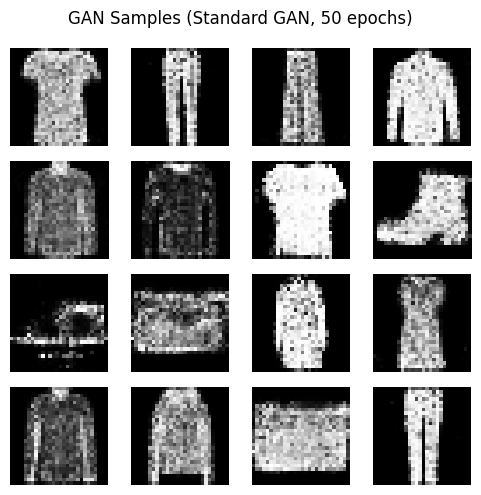

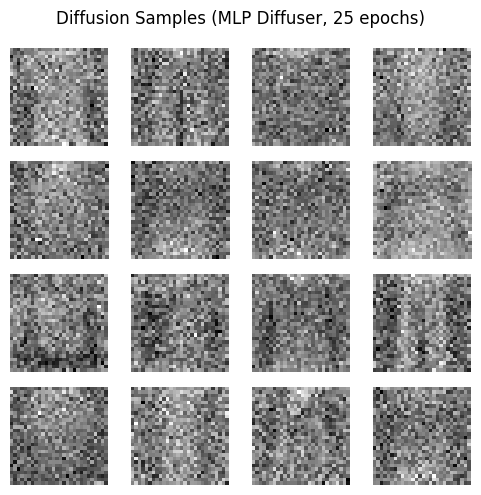

In [ ]:
# GAN samples 
G_std.eval()
with torch.no_grad():
    z = torch.randn(16, n_noise).to(DEVICE)
    gan_samples = G_std(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(gan_samples[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('GAN Samples (Standard GAN, 50 epochs)')
plt.tight_layout()
plt.show()

# Diffusion samples 
diff_model.eval()
noisy = (unit_normal.sample((16, 1, 28, 28)) * np.sqrt(noise_steps))
labels16 = torch.tensor([i % 10 for i in range(16)])
with torch.no_grad():
    for t in range(noise_steps):
        noise_level = noise_steps - t - 1
        noise = diff_model(noisy, noise_level, labels16)
        noisy -= noise

fig, axes = plt.subplots(4, 4, figsize=(5, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(noisy[i].cpu().squeeze(), cmap='gray')
    ax.axis('off')
plt.suptitle('Diffusion Samples (MLP Diffuser, 25 epochs)')
plt.tight_layout()
plt.show()

##### The GAN grid shows sharp, high-contrast garments with clearly defined silhouettes. The diffusion grid shows faint, blurry outputs with visible noise. Both grids use the same MLP scale, confirming the quality gap is due to the adversarial training signal in the GAN rather than any difference in model capacity.